# 🧠 NIFTY AI Trading Intelligence — Model Training
**Models:** Market Direction Predictor + Volatility Predictor  
**Algorithm:** XGBoost  
**Data:** Consolidated NIFTY historical data (2000–2026)

## 📦 Cell 1 — Install & Import Libraries

In [1]:
# Install required libraries (only needed in Colab)
!pip install xgboost scikit-learn openpyxl joblib --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## 📂 Cell 2 — Upload & Load Excel File
> If on **Google Colab**, run the upload cell below.  
> If on **Jupyter local**, just set the file path directly.

In [3]:
# ── FOR GOOGLE COLAB: Upload your file ──────────────────────────────────
from google.colab import files
uploaded = files.upload()  # uncomment this if on Colab

# ── SET YOUR FILE PATH ───────────────────────────────────────────────────
FILE_PATH = 'Consolidated sheet Nifty.xlsx'  # change if needed

# Load all sheets
all_sheets = pd.read_excel(FILE_PATH, sheet_name=None)

print(f'✅ File loaded successfully')
print(f'📅 Sheets found: {list(all_sheets.keys())}')

Saving Consolidated sheet Nifty.xlsx to Consolidated sheet Nifty.xlsx
✅ File loaded successfully
📅 Sheets found: ['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']


## 🔗 Cell 3 — Merge All Yearly Sheets Into One DataFrame

In [4]:
dfs = []

for year, df in all_sheets.items():
    try:
        clean = df[['Date', 'Open', 'High', 'Low', 'Close',
                    'High-Low', 'Prev. cl Diff.', '%age PY Cl.']].copy()
        clean.columns = ['Date', 'Open', 'High', 'Low', 'Close',
                         'HL_Range', 'Prev_Diff', 'Pct_Change']
        clean['Year'] = year
        dfs.append(clean)
    except Exception as e:
        print(f'⚠️  Skipped sheet {year}: {e}')

df = pd.concat(dfs, ignore_index=True)
df = df.sort_values('Date').reset_index(drop=True)

# Convert to numeric safely
for col in ['Open', 'High', 'Low', 'Close', 'HL_Range', 'Prev_Diff', 'Pct_Change']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'✅ Total rows merged: {len(df)}')
print(f'📆 Date range: {df["Date"].min()} → {df["Date"].max()}')
df.head()

✅ Total rows merged: 6523
📆 Date range: 2000-01-03 00:00:00 → 2026-03-13 00:00:00


,Date,Open,High,Low,Close,HL_Range,Prev_Diff,Pct_Change,Year
0,2000-01-03,1482.15,1592.90,1482.15,1592.2,110.75,NaN,NaN,2000
1,2000-01-04,1594.40,1641.95,1594.40,1638.7,47.55,46.5,2.920487,2000
2,2000-01-05,1634.55,1635.50,1555.05,1595.8,80.45,-42.9,-2.617929,2000
3,2000-01-06,1595.80,1639.00,1595.80,1617.6,43.20,21.8,1.366086,2000
4,2000-01-07,1616.60,1628.25,1597.20,1613.3,31.05,-4.3,-0.265826,2000


## 🔧 Cell 4 — Feature Engineering

In [5]:
# Moving averages
df['MA5']       = df['Close'].rolling(5).mean()
df['MA20']      = df['Close'].rolling(20).mean()
df['MA50']      = df['Close'].rolling(50).mean()

# Momentum
df['Momentum']  = df['Close'] - df['Close'].shift(5)

# Price vs moving average ratio
df['Close_MA5_Ratio']  = df['Close'] / df['MA5']
df['Close_MA20_Ratio'] = df['Close'] / df['MA20']

# Volatility rolling
df['Rolling_Vol'] = df['HL_Range'].rolling(5).mean()

print('✅ Features engineered:')
print(['MA5', 'MA20', 'MA50', 'Momentum', 'Close_MA5_Ratio',
       'Close_MA20_Ratio', 'Rolling_Vol'])

✅ Features engineered:
['MA5', 'MA20', 'MA50', 'Momentum', 'Close_MA5_Ratio', 'Close_MA20_Ratio', 'Rolling_Vol']


## 🏷️ Cell 5 — Create Labels (Direction & Volatility)

In [6]:
# ── Direction Label ───────────────────────────────────────────────────────
# What does price do the NEXT day?
df['Next_Close'] = df['Close'].shift(-1)

def direction_label(row):
    if pd.isna(row['Next_Close']):
        return np.nan
    if row['Next_Close'] > row['Close'] * 1.003:    # UP = +0.3%
        return 'UP'
    elif row['Next_Close'] < row['Close'] * 0.997:  # DOWN = -0.3%
        return 'DOWN'
    else:
        return 'SIDEWAYS'

df['Direction'] = df.apply(direction_label, axis=1)

# ── Volatility Label ──────────────────────────────────────────────────────
df['Volatility'] = pd.cut(
    df['HL_Range'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

print('✅ Labels created')
print('\n📊 Direction distribution:')
print(df['Direction'].value_counts())
print('\n📊 Volatility distribution:')
print(df['Volatility'].value_counts())

✅ Labels created

📊 Direction distribution:
Direction
UP          2637
DOWN        2197
SIDEWAYS    1681
Name: count, dtype: int64

📊 Volatility distribution:
Volatility
Low       6492
Medium      14
High         2
Name: count, dtype: int64


## 📊 Cell 6 — Visualize Label Distribution

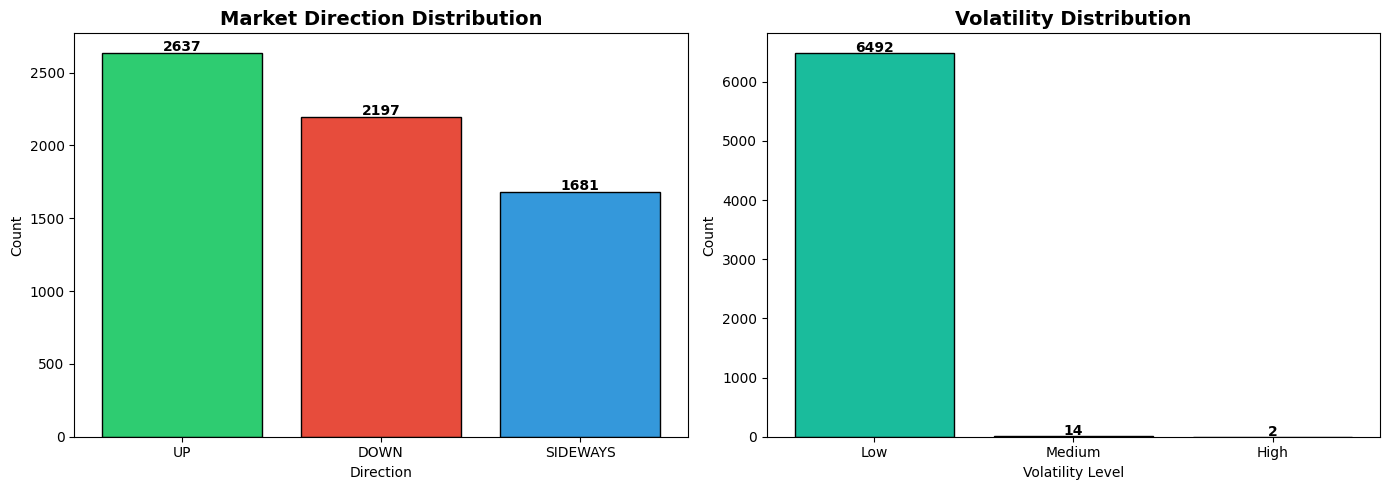

✅ Chart saved as label_distribution.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Direction distribution
dir_counts = df['Direction'].value_counts()
colors_dir = ['#2ecc71', '#e74c3c', '#3498db']
axes[0].bar(dir_counts.index, dir_counts.values, color=colors_dir, edgecolor='black')
axes[0].set_title('Market Direction Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Direction')
axes[0].set_ylabel('Count')
for i, v in enumerate(dir_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Volatility distribution
vol_counts = df['Volatility'].value_counts().sort_index()
colors_vol = ['#1abc9c', '#f39c12', '#e74c3c']
axes[1].bar(vol_counts.index, vol_counts.values, color=colors_vol, edgecolor='black')
axes[1].set_title('Volatility Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Volatility Level')
axes[1].set_ylabel('Count')
for i, v in enumerate(vol_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as label_distribution.png')

## ✂️ Cell 7 — Prepare Features & Split Data

In [8]:
FEATURES = [
    'Open', 'High', 'Low', 'Close',
    'HL_Range', 'Prev_Diff', 'Pct_Change',
    'MA5', 'MA20', 'MA50',
    'Momentum', 'Close_MA5_Ratio',
    'Close_MA20_Ratio', 'Rolling_Vol'
]

# Drop NaN from ALL columns together so X and y always match
df_clean = df[FEATURES + ['Direction', 'Volatility']].dropna()

X = df_clean[FEATURES]

le_dir = LabelEncoder()
le_vol = LabelEncoder()
y_dir = le_dir.fit_transform(df_clean['Direction'])
y_vol = le_vol.fit_transform(df_clean['Volatility'])

# shuffle=False is CRITICAL for time series — never shuffle financial data
X_train, X_test, y_dir_train, y_dir_test = train_test_split(
    X, y_dir, test_size=0.2, shuffle=False)

_, _, y_vol_train, y_vol_test = train_test_split(
    X, y_vol, test_size=0.2, shuffle=False)

print(f'✅ Data split complete')
print(f'   X shape      : {X.shape}')
print(f'   X_train      : {X_train.shape}')
print(f'   X_test       : {X_test.shape}')
print(f'   y_dir classes: {le_dir.classes_}')
print(f'   y_vol classes: {le_vol.classes_}')

✅ Data split complete
   X shape      : (6419, 14)
   X_train      : (5135, 14)
   X_test       : (1284, 14)
   y_dir classes: ['DOWN' 'SIDEWAYS' 'UP']
   y_vol classes: ['High' 'Low' 'Medium']


## 🤖 Cell 8 — Train Direction Model (UP / DOWN / SIDEWAYS)

In [9]:
print('🚀 Training Direction Model...')

dir_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

dir_model.fit(
    X_train, y_dir_train,
    eval_set=[(X_test, y_dir_test)],
    verbose=False
)

y_dir_pred = dir_model.predict(X_test)
dir_accuracy = accuracy_score(y_dir_test, y_dir_pred)

print(f'\n✅ Direction Model Trained!')
print(f'   Accuracy: {dir_accuracy:.2%}')
print(f'\n📋 Classification Report:')
print(classification_report(y_dir_test, y_dir_pred, target_names=le_dir.classes_))

🚀 Training Direction Model...

✅ Direction Model Trained!
   Accuracy: 36.37%

📋 Classification Report:
              precision    recall  f1-score   support

        DOWN       0.13      0.01      0.01       391
    SIDEWAYS       0.38      0.06      0.11       425
          UP       0.37      0.94      0.53       468

    accuracy                           0.36      1284
   macro avg       0.29      0.33      0.22      1284
weighted avg       0.30      0.36      0.23      1284



## 🌊 Cell 9 — Train Volatility Model (Low / Medium / High)

In [10]:
print('🚀 Training Volatility Model...')

vol_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

vol_model.fit(
    X_train, y_vol_train,
    eval_set=[(X_test, y_vol_test)],
    verbose=False
)

y_vol_pred = vol_model.predict(X_test)
vol_accuracy = accuracy_score(y_vol_test, y_vol_pred)

print(f'\n✅ Volatility Model Trained!')
print(f'   Accuracy: {vol_accuracy:.2%}')
print(f'\n📋 Classification Report:')
print(classification_report(y_vol_test, y_vol_pred, target_names=le_vol.classes_))

🚀 Training Volatility Model...

✅ Volatility Model Trained!
   Accuracy: 98.60%

📋 Classification Report:
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         1
         Low       1.00      0.99      0.99      1279
      Medium       0.16      0.75      0.26         4

    accuracy                           0.99      1284
   macro avg       0.39      0.58      0.42      1284
weighted avg       1.00      0.99      0.99      1284



## 📉 Cell 10 — Confusion Matrices

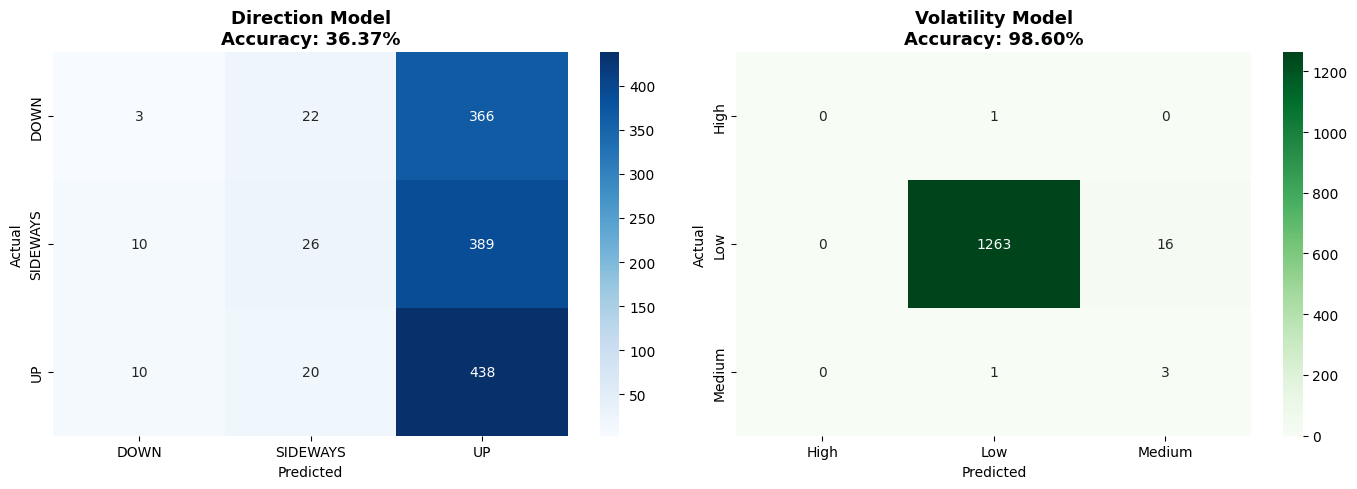

✅ Confusion matrices saved


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Direction confusion matrix
cm_dir = confusion_matrix(y_dir_test, y_dir_pred)
sns.heatmap(cm_dir, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_dir.classes_,
            yticklabels=le_dir.classes_, ax=axes[0])
axes[0].set_title(f'Direction Model\nAccuracy: {dir_accuracy:.2%}',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Volatility confusion matrix
cm_vol = confusion_matrix(y_vol_test, y_vol_pred)
sns.heatmap(cm_vol, annot=True, fmt='d', cmap='Greens',
            xticklabels=le_vol.classes_,
            yticklabels=le_vol.classes_, ax=axes[1])
axes[1].set_title(f'Volatility Model\nAccuracy: {vol_accuracy:.2%}',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrices saved')

## 📌 Cell 11 — Feature Importance

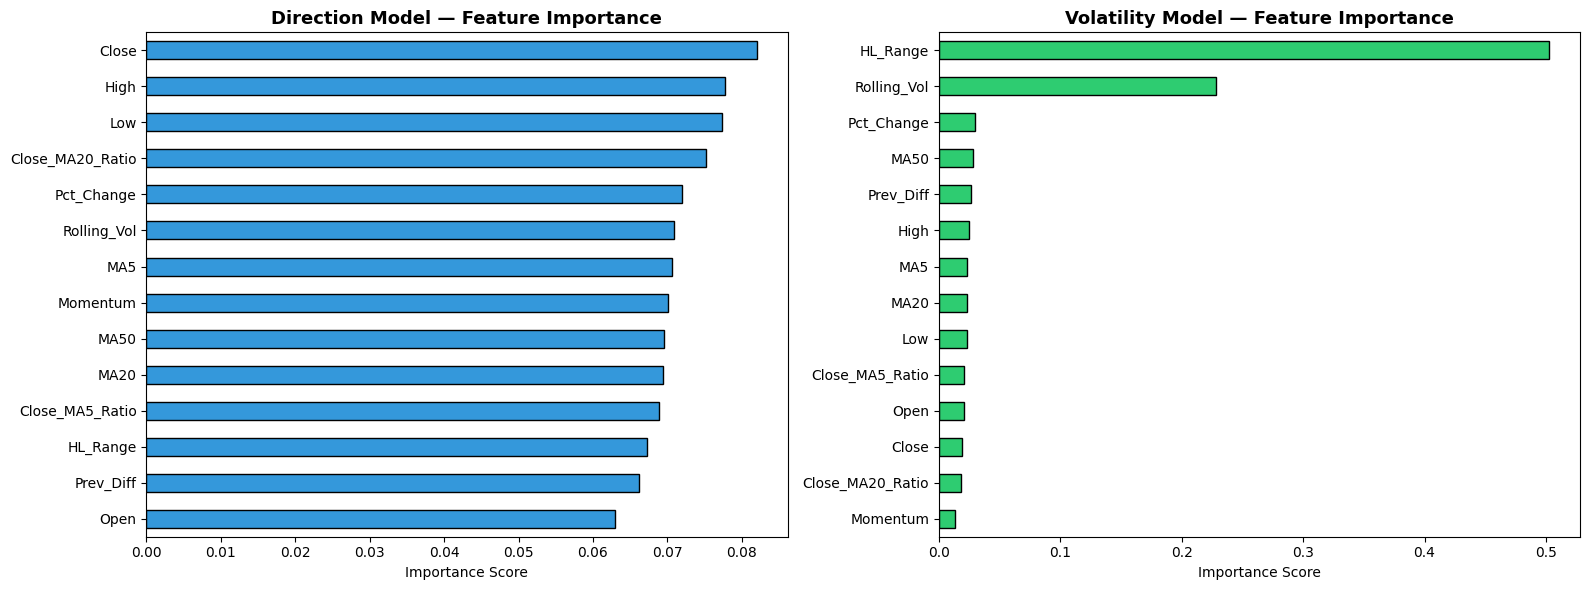

✅ Feature importance chart saved


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model, title, color in zip(
    axes,
    [dir_model, vol_model],
    ['Direction Model — Feature Importance', 'Volatility Model — Feature Importance'],
    ['#3498db', '#2ecc71']
):
    importances = pd.Series(model.feature_importances_, index=FEATURES)
    importances = importances.sort_values(ascending=True)
    importances.plot(kind='barh', ax=ax, color=color, edgecolor='black')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Feature importance chart saved')

## 💾 Cell 12 — Save Models & Encoders

In [13]:
joblib.dump(dir_model, 'direction_model.pkl')
joblib.dump(vol_model, 'volatility_model.pkl')
joblib.dump(le_dir,    'label_encoder_direction.pkl')
joblib.dump(le_vol,    'label_encoder_volatility.pkl')
joblib.dump(FEATURES,  'feature_list.pkl')

print('✅ All models and encoders saved!')
print('   📁 direction_model.pkl')
print('   📁 volatility_model.pkl')
print('   📁 label_encoder_direction.pkl')
print('   📁 label_encoder_volatility.pkl')
print('   📁 feature_list.pkl')

✅ All models and encoders saved!
   📁 direction_model.pkl
   📁 volatility_model.pkl
   📁 label_encoder_direction.pkl
   📁 label_encoder_volatility.pkl
   📁 feature_list.pkl


## 🎯 Cell 13 — Test Live Prediction (Single Day)

In [14]:
# Simulate what the FastAPI backend will do with live yfinance data
sample = X_test.iloc[[-1]]  # take last row as example

dir_pred  = le_dir.inverse_transform(dir_model.predict(sample))[0]
vol_pred  = le_vol.inverse_transform(vol_model.predict(sample))[0]
dir_proba = dir_model.predict_proba(sample)[0]

# Strategy recommendation logic
strategy_map = {
    ('UP',       'Low'):    'Bull Call Spread',
    ('UP',       'Medium'): 'Long Call',
    ('UP',       'High'):   'Long Call (aggressive)',
    ('DOWN',     'Low'):    'Bear Put Spread',
    ('DOWN',     'Medium'): 'Long Put',
    ('DOWN',     'High'):   'Long Put (aggressive)',
    ('SIDEWAYS', 'Low'):    'Iron Condor',
    ('SIDEWAYS', 'Medium'): 'Short Strangle',
    ('SIDEWAYS', 'High'):   'Short Straddle',
}
strategy = strategy_map.get((dir_pred, vol_pred), 'No clear strategy')

print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('         🎯 PREDICTION OUTPUT')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  Market Direction : {dir_pred}')
print(f'  Volatility       : {vol_pred}')
print(f'  Suggested Strategy: {strategy}')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  Probabilities:')
for cls, prob in zip(le_dir.classes_, dir_proba):
    bar = '█' * int(prob * 30)
    print(f'    {cls:<10} {bar} {prob:.1%}')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
         🎯 PREDICTION OUTPUT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Market Direction : UP
  Volatility       : Low
  Suggested Strategy: Bull Call Spread
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Probabilities:
    DOWN       ██ 7.6%
    SIDEWAYS   ███ 10.1%
    UP         ████████████████████████ 82.3%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## ⬇️ Cell 14 — Download Models (Google Colab only)

In [15]:
# Uncomment below lines if you are on Google Colab
from google.colab import files
files.download('direction_model.pkl')
files.download('volatility_model.pkl')
files.download('label_encoder_direction.pkl')
files.download('label_encoder_volatility.pkl')
files.download('feature_list.pkl')

print('📦 Once downloaded, place these .pkl files in your VS Code project:')
print('   backend/')
print('   └── models/')
print('       ├── direction_model.pkl')
print('       ├── volatility_model.pkl')
print('       ├── label_encoder_direction.pkl')
print('       ├── label_encoder_volatility.pkl')
print('       └── feature_list.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📦 Once downloaded, place these .pkl files in your VS Code project:
   backend/
   └── models/
       ├── direction_model.pkl
       ├── volatility_model.pkl
       ├── label_encoder_direction.pkl
       ├── label_encoder_volatility.pkl
       └── feature_list.pkl
